# Mission Partie 1 : Analyse Exploratoire

Ce notebook présente la phase d'analyse exploratoire et de nettoyage des données de consommation d'énergie des bâtiments non résidentiels de la ville de Seattle pour l'année 2016.


## 1. Initialisation de l'environnement


In [2]:
# Ce notebook est configuré pour tourner localement sur ton ordinateur.
import os
import pandas as pd

# Répertoire racine
PROJECT_ROOT = '.'

# Création du répertoire de sauvegarde
os.makedirs(f'{PROJECT_ROOT}/model', exist_ok=True)

print(f'Environnement local prêt. Répertoire projet : {os.getcwd()}')


Environnement local prêt. Répertoire projet : c:\Users\docje\.gemini\antigravity\scratch\Projet 6\Projet-6-Anticipez-les-besoins-en-consommation-de-b-timents-main


## 2. Configuration des accès aux données


In [3]:

# Chargement du fichier de données
DATA_PATH = f'{PROJECT_ROOT}/2016_Building_Energy_Benchmarking.csv'

if os.path.exists(DATA_PATH):
    print(f'CSV trouvé : {DATA_PATH}')
else:
    print(f'ERREUR : Le fichier {DATA_PATH} est introuvable. Assure-toi de l\'avoir collé dans ce dossier.')

# Répertoire du modèle
MODEL_DIR = f'{PROJECT_ROOT}/model'
print(f'Modèle sauvegardé dans : {MODEL_DIR}')


CSV trouvé : ./2016_Building_Energy_Benchmarking.csv
Modèle sauvegardé dans : ./model


# 3. Analyse Exploratoire des Données


### Import des modules


In [4]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)

# 3. Analyse Exploratoire des Données


In [5]:
building_consumption = pd.read_csv(DATA_PATH)
print(f"Dimensions du DataFrame: {building_consumption.shape[0]} lignes, {building_consumption.shape[1]} colonnes")

Dimensions du DataFrame: 3376 lignes, 46 colonnes


In [6]:
# Premier aperçu des données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [7]:
# Analyse des types et des valeurs manquantes 
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [8]:
# Statistiques descriptives de base
building_consumption.iloc[:, :30].describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf)
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,3376.000000,3.376000e+03,3.356000e+03,1679.000000,596.000000,2533.000000,3369.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,8001.526066,8.683201e+04,7.917764e+04,28444.075817,11738.675166,67.918674,54.732116
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,32326.723928,2.079398e+05,2.017034e+05,54392.917928,29331.199286,26.873271,56.273124
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,0.000000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,0.000000,2.775600e+04,2.509475e+04,5000.000000,2239.000000,53.000000,27.900000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,0.000000,4.321600e+04,3.989400e+04,10664.000000,5043.000000,75.000000,38.599998
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,0.000000,8.427625e+04,7.620025e+04,26640.000000,10138.750000,90.000000,60.400002
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,686750.000000,459748.000000,100.000000,834.400024


### 3.1. Analyse et traitement des valeurs manquantes

Nous identifions et écartons les variables contenant un trop grand nombre de données absentes (seuil de tolérance fixé à 70 %).


In [9]:
# Taux de valeurs manquantes par variable
missing_pct = (building_consumption.isnull().mean().sort_values(ascending=False) * 100).round(2)
print("Valeurs manquantes (%) :")
print(missing_pct[missing_pct > 0])

# Suppression des colonnes présentant trop de NaN (seuil à 70%)
seuil = 0.7
cols_to_drop = building_consumption.columns[building_consumption.isna().mean() >= seuil]
print(f"\nColonnes supprimées (>={int(seuil*100)}% NA) : {list(cols_to_drop)}")
print(f"Nombre de colonnes supprimées : {len(cols_to_drop)}")
building_consumption = building_consumption.drop(columns=cols_to_drop)
print(f"Dimensions après suppression : {building_consumption.shape}")

Valeurs manquantes (%) :
Comments                           100.00
Outlier                             99.05
YearsENERGYSTARCertified            96.48
ThirdLargestPropertyUseType         82.35
ThirdLargestPropertyUseTypeGFA      82.35
SecondLargestPropertyUseType        50.27
SecondLargestPropertyUseTypeGFA     50.27
ENERGYSTARScore                     24.97
LargestPropertyUseTypeGFA            0.59
LargestPropertyUseType               0.59
ZipCode                              0.47
ListOfAllPropertyUseTypes            0.27
SourceEUIWN(kBtu/sf)                 0.27
SourceEUI(kBtu/sf)                   0.27
Electricity(kWh)                     0.27
Electricity(kBtu)                    0.27
NaturalGas(therms)                   0.27
NaturalGas(kBtu)                     0.27
TotalGHGEmissions                    0.27
SteamUse(kBtu)                       0.27
GHGEmissionsIntensity                0.27
NumberofBuildings                    0.24
SiteEUI(kBtu/sf)                     0.21
SiteEUIWN

### 3.2. Analyse du type de bâtiment (BuildingType)

La mission se concentrant uniquement sur les bâtiments commerciaux et administratifs, nous excluons les habitations collectives (Multifamily).


,Nombre,Pourcentage (%)
BuildingType,,
NonResidential,1460.0,43.25
Multifamily LR (1-4),1018.0,30.15
Multifamily MR (5-9),580.0,17.18
Multifamily HR (10+),110.0,3.26
SPS-District K-12,98.0,2.90
Nonresidential COS,85.0,2.52
Campus,24.0,0.71
Nonresidential WA,1.0,0.03
Total,3376.0,100.00


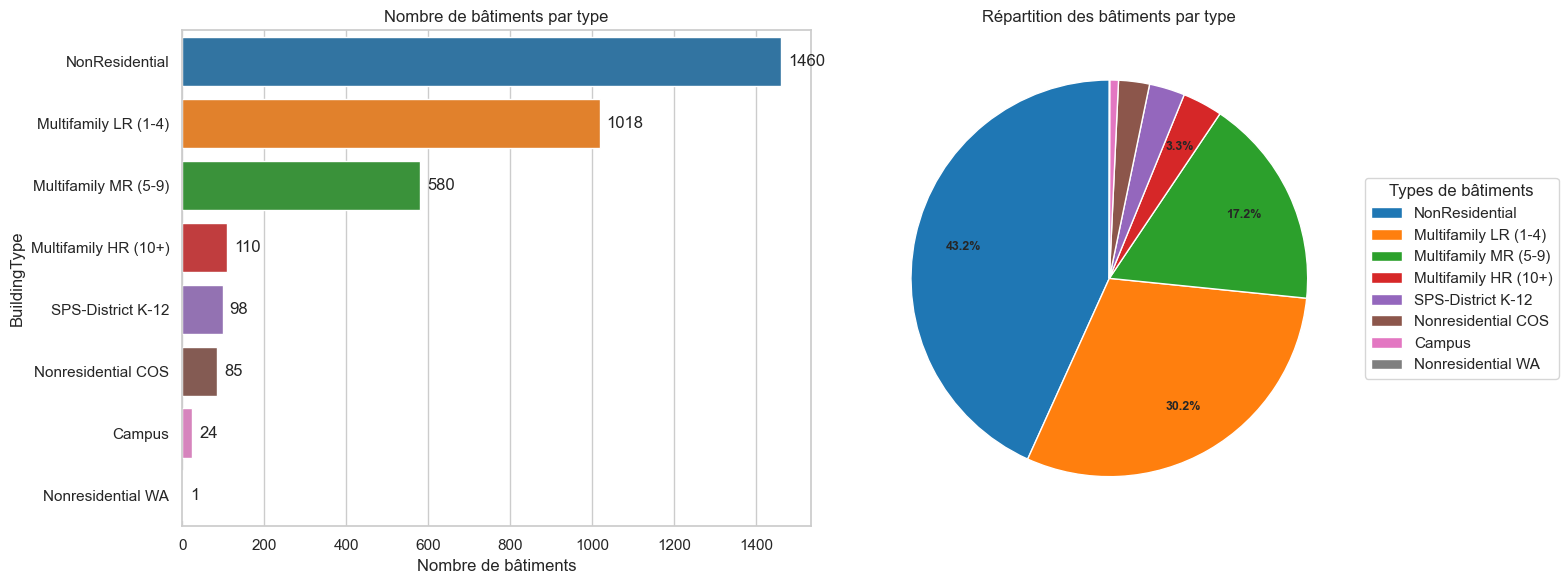

In [10]:
# Répartition des types de bâtiments
bt_counts = building_consumption['BuildingType'].value_counts()
bt_percent = (building_consumption['BuildingType'].value_counts(normalize=True) * 100).round(2)

bt_df = pd.DataFrame({'Nombre': bt_counts, 'Pourcentage (%)': bt_percent})
bt_df.loc['Total'] = [bt_counts.sum(), 100.0]
display(bt_df)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.barplot(x=bt_counts.values, y=bt_counts.index, palette='tab10', ax=ax)
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}", (p.get_width(), p.get_y()+p.get_height()/2),
                xytext=(5,0), textcoords='offset points', va='center')
ax.set_xlabel("Nombre de bâtiments")
ax.set_title("Nombre de bâtiments par type")


ax = axes[1]
# Camembert épuré pour éviter le chevauchement des étiquettes
wedges, texts, autotexts = ax.pie(
    bt_counts,
    labels=None,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 3.0 else '',
    startangle=90,
    colors=sns.color_palette('tab10', len(bt_counts)),
    pctdistance=0.75
)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_weight('bold')

ax.legend(
    wedges,
    bt_counts.index,
    title="Types de bâtiments",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)
ax.set_title("Répartition des bâtiments par type")

plt.tight_layout()
plt.show()

### 3.2. Analyse temporelle des constructions

Nous étudions l'évolution temporelle du nombre de bâtiments construits à Seattle pour comprendre l'ancienneté du parc immobilier.

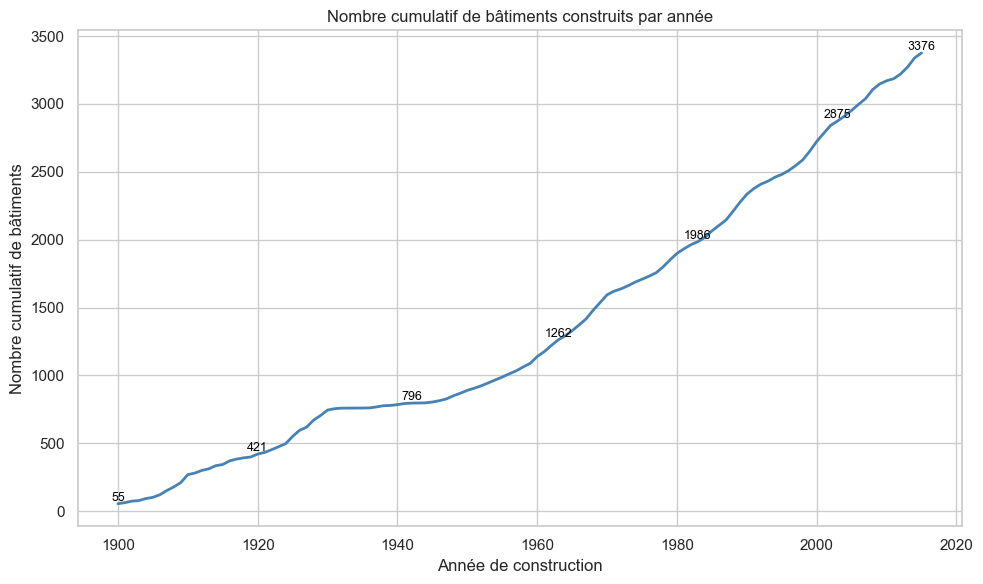

In [11]:
# Calcul du nombre cumulatif de bâtiments construits par année
buildings_per_year = building_consumption['YearBuilt'].value_counts().sort_index()
cumulative_buildings = buildings_per_year.cumsum()

plt.figure(figsize=(10,6))
sns.lineplot(x=cumulative_buildings.index.values, y=cumulative_buildings.values, color='steelblue', linewidth=2)
plt.xlabel("Année de construction")
plt.ylabel("Nombre cumulatif de bâtiments")
plt.title("Nombre cumulatif de bâtiments construits par année")

# Affichage des repères de valeurs tous les 20 ans
for year in cumulative_buildings.index[::20]:
    value = cumulative_buildings.loc[year]
    plt.text(year, value, f"{value}", ha='center', va='bottom', fontsize=9, color='black')

# Repère pour la dernière année disponible
last_year = cumulative_buildings.index[-1]
if last_year not in cumulative_buildings.index[::20]:
    value = cumulative_buildings.loc[last_year]
    plt.text(last_year, value, f"{value}", ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.show()


In [12]:
# Filtrage pour ne conserver que le non-résidentiel
residential_types = ["Multifamily LR (1-4)", "Multifamily MR (5-9)", "Multifamily HR (10+)"]

print(f"Lignes avant filtrage : {building_consumption.shape[0]}")
mask_residential = building_consumption['BuildingType'].isin(residential_types)
print(f"Bâtiments résidentiels à supprimer : {mask_residential.sum()}")

building_consumption = building_consumption.loc[~mask_residential].copy()
print(f"Lignes après suppression des résidentiels : {building_consumption.shape[0]}")
print(f"\nTypes restants :")
print(building_consumption['BuildingType'].value_counts())

Lignes avant filtrage : 3376
Bâtiments résidentiels à supprimer : 1708
Lignes après suppression des résidentiels : 1668

Types restants :
BuildingType
NonResidential        1460
SPS-District K-12       98
Nonresidential COS      85
Campus                  24
Nonresidential WA        1
Name: count, dtype: int64


### 3.3. Comparaison détaillée : Bâtiments Résidentiels vs Non-Résidentiels

Nous visualisons la répartition détaillée pour justifier l'exclusion des logements collectifs (Multifamily) de notre modèle de prédiction.

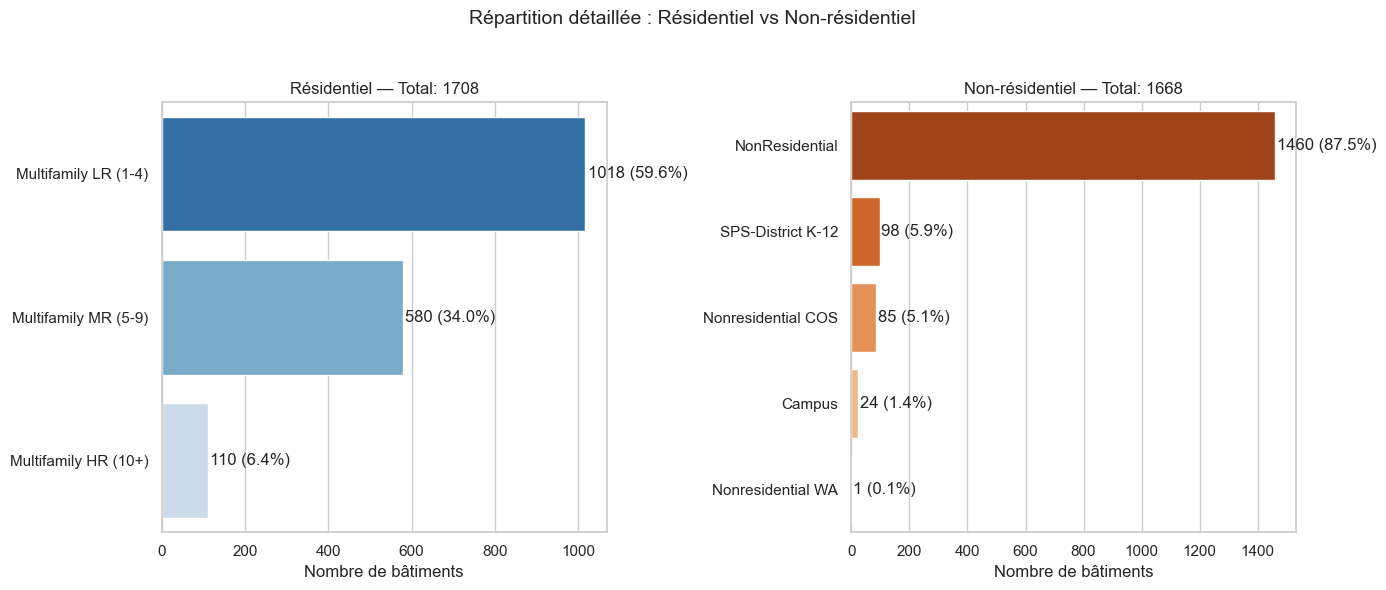

In [13]:
# Répartition détaillée résidentiel vs non-résidentiel
residential_types = ["Multifamily LR (1-4)", "Multifamily MR (5-9)", "Multifamily HR (10+)"]

# Récupération des counts d'origine à partir du dataframe brut (chargé en mémoire)
raw_data = pd.read_csv(DATA_PATH)
res_counts = raw_data[raw_data['BuildingType'].isin(residential_types)]['BuildingType'].value_counts()
nonres_counts = raw_data[~raw_data['BuildingType'].isin(residential_types)]['BuildingType'].value_counts()

total_res = res_counts.sum()
total_nonres = nonres_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barplot Résidentiel
ax = axes[0]
sns.barplot(x=res_counts.values, y=res_counts.index, palette="Blues_r", ax=ax)
ax.set_title(f"Résidentiel — Total: {total_res}")
ax.set_xlabel("Nombre de bâtiments")
ax.set_ylabel("")
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    pct = (width / total_res * 100) if total_res > 0 else 0
    ax.text(width + 5, y, f"{int(width)} ({pct:.1f}%)", va='center')

# Barplot Non-résidentiel
ax = axes[1]
sns.barplot(x=nonres_counts.values, y=nonres_counts.index, palette="Oranges_r", ax=ax)
ax.set_title(f"Non-résidentiel — Total: {total_nonres}")
ax.set_xlabel("Nombre de bâtiments")
ax.set_ylabel("")
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    pct = (width / total_nonres * 100) if total_nonres > 0 else 0
    ax.text(width + 5, y, f"{int(width)} ({pct:.1f}%)", va='center')

plt.suptitle("Répartition détaillée : Résidentiel vs Non-résidentiel", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### 3.3. Distribution de la variable cible : SiteEnergyUse(kBtu)

Nous étudions la distribution de la consommation énergétique pour analyser son asymétrie et évaluer la pertinence d'une transformation logarithmique.


Statistiques de la cible 'SiteEnergyUse(kBtu)':
count    1.666000e+03
mean     8.437933e+06
std      3.024380e+07
min      0.000000e+00
25%      1.229291e+06
50%      2.554947e+06
75%      6.913348e+06
max      8.739237e+08
Name: SiteEnergyUse(kBtu), dtype: float64

Valeurs manquantes : 2


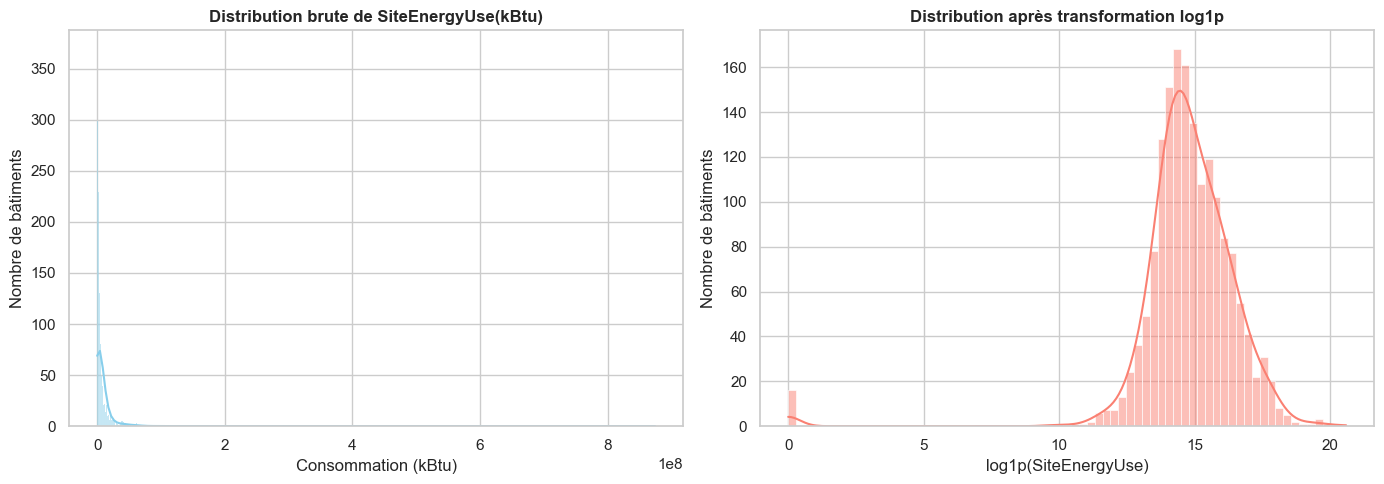

In [14]:
target = "SiteEnergyUse(kBtu)"

print(f"Statistiques de la cible '{target}':")
print(building_consumption[target].describe())
print(f"\nValeurs manquantes : {building_consumption[target].isna().sum()}")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style graphique
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Distribution brute (Asymétrique)
sns.histplot(building_consumption['SiteEnergyUse(kBtu)'].dropna(), kde=True, color='skyblue', ax=axes[0])
axes[0].set_title("Distribution brute de SiteEnergyUse(kBtu)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Consommation (kBtu)")
axes[0].set_ylabel("Nombre de bâtiments")

# Graphique 2 : Distribution après transformation Log1p (Normale)
sns.histplot(np.log1p(building_consumption['SiteEnergyUse(kBtu)'].dropna()), kde=True, color='salmon', ax=axes[1])
axes[1].set_title("Distribution après transformation log1p", fontsize=12, fontweight='bold')
axes[1].set_xlabel("log1p(SiteEnergyUse)")
axes[1].set_ylabel("Nombre de bâtiments")

plt.tight_layout()
plt.show()


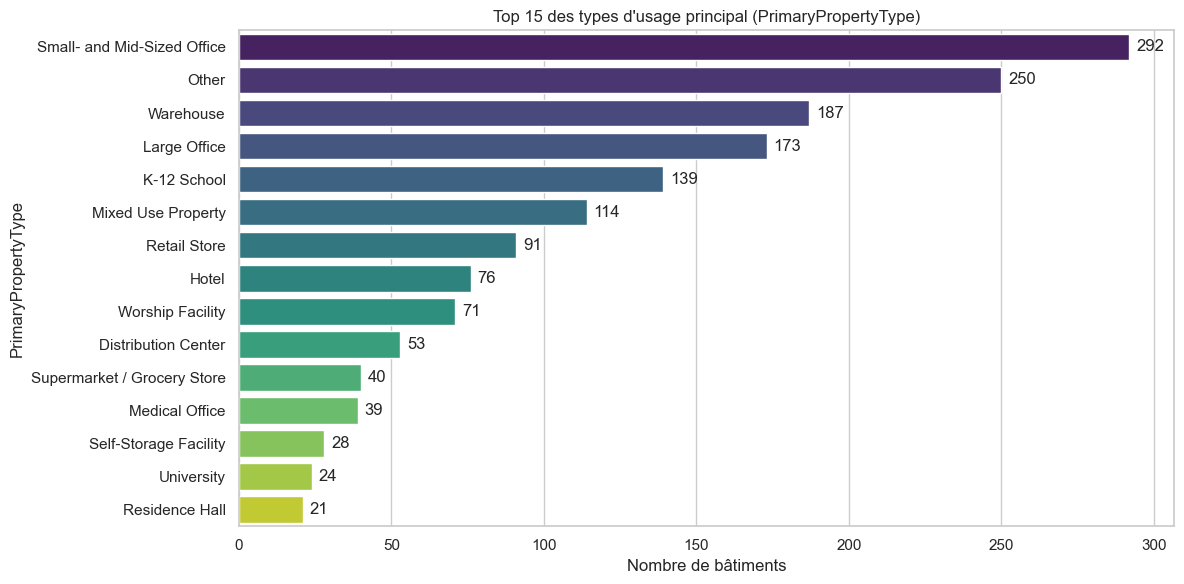

In [15]:
# Top 15 des types d'usage principal
ppt_counts = building_consumption['PrimaryPropertyType'].value_counts()

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=ppt_counts.head(15).values, y=ppt_counts.head(15).index, palette='viridis')
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}", (p.get_width(), p.get_y()+p.get_height()/2),
                xytext=(5,0), textcoords='offset points', va='center')
plt.xlabel("Nombre de bâtiments")
plt.title("Top 15 des types d'usage principal (PrimaryPropertyType)")
plt.tight_layout()
plt.show()

Corrélation avec la cible :
SiteEnergyUse(kBtu)                1.000000
Electricity(kWh)                   0.956264
Electricity(kBtu)                  0.956264
TotalGHGEmissions                  0.859940
LargestPropertyUseTypeGFA          0.841987
PropertyGFABuilding(s)             0.819630
PropertyGFATotal                   0.804162
NumberofBuildings                  0.712977
SiteEnergyUseWN(kBtu)              0.704050
SecondLargestPropertyUseTypeGFA    0.631359
SteamUse(kBtu)                     0.605002
NaturalGas(therms)                 0.503369
NaturalGas(kBtu)                   0.503369
GHGEmissionsIntensity              0.298053
SiteEUI(kBtu/sf)                   0.272841
SourceEUI(kBtu/sf)                 0.270029
SiteEUIWN(kBtu/sf)                 0.243171
SourceEUIWN(kBtu/sf)               0.241311
NumberofFloors                     0.220100
PropertyGFAParking                 0.146116
YearBuilt                          0.062774
CouncilDistrictCode                0.048573
Long

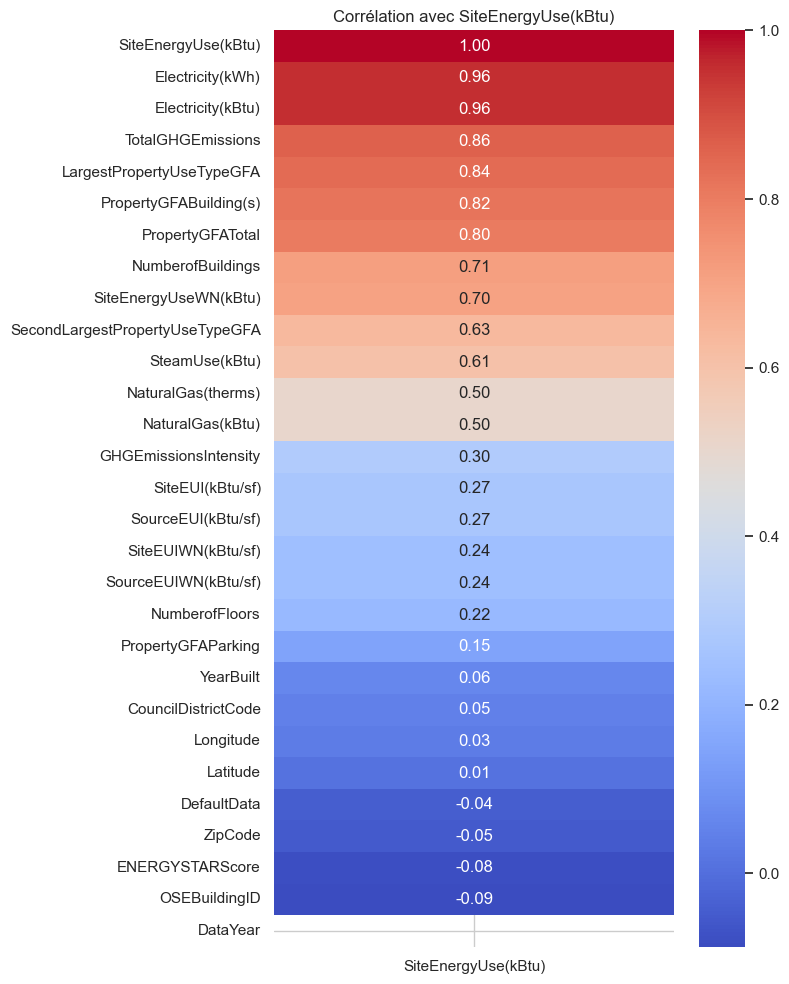

In [16]:
# Matrice de corrélation linéaire avec la cible
corr_target = building_consumption.corr(numeric_only=True)[target].sort_values(ascending=False)
print("Corrélation avec la cible :")
print(corr_target)

plt.figure(figsize=(8, 10))
sns.heatmap(corr_target.to_frame(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title(f"Corrélation avec {target}")
plt.tight_layout()
plt.show()

### 3.4. Synthèse de l'Analyse Exploratoire

Cette première phase d'exploration a permis de :
* Nettoyer les données en excluant les colonnes presque vides et les bâtiments résidentiels.
* Identifier la surface totale (`PropertyGFATotal`) comme la variable quantitative la plus corrélée avec la consommation d'énergie.
* Confirmer la nécessité d'appliquer une transformation logarithmique (`log1p`) sur la cible afin de régulariser la distribution pour les modèles linéaires et les algorithmes d'arbres.

Les données sont prêtes à être transmises à l'étape suivante de Feature Engineering et de Modélisation.
